# 05 - ECE Bug Fix: Confidence-1.0 Predictions Were Silently Dropped

`quantumuq.core.metrics.ece` binned confidences with equal-width bins using
`bin_edges[i] <= confidence < bin_edges[i+1]`. The **last** bin therefore
excluded any prediction with confidence exactly `1.0`, since
`confidence < bin_edges[-1]` (`bin_edges[-1] == 1.0`) is `False` for those
points. Those predictions contributed to neither the bin's accuracy nor its
weight, so a model that is *fully confident and always wrong* reported
**ECE = 0.0** instead of **ECE ~ 1.0**.

The fix makes the last bin's upper edge inclusive (`<=`) so confidence-1.0
predictions are counted like any other point.

This notebook:
1. Reproduces the bug against a local copy of the old implementation.
2. Shows a realistic case where it bites: single-shot quantum measurements,
   which saturate to exact 0/1 probabilities.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from quantumuq import ece
from quantumuq.datasets.toy import make_moons


def ece_buggy(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 15) -> float:
    """Pre-fix implementation, kept here only for comparison."""
    y_true = np.asarray(y_true, dtype=int)
    p_pred = np.asarray(p_pred, dtype=float)
    confidences = p_pred.max(axis=1)
    predictions = p_pred.argmax(axis=1)
    accuracies = predictions == y_true

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece_val = 0.0
    for i in range(n_bins):
        mask = (confidences >= bin_edges[i]) & (confidences < bin_edges[i + 1])
        if not np.any(mask):
            continue
        bin_conf = confidences[mask].mean()
        bin_acc = accuracies[mask].mean()
        weight = mask.mean()
        ece_val += weight * abs(bin_acc - bin_conf)
    return float(ece_val)

## 1. Minimal synthetic repro

In [2]:
cases = {
    "confidently WRONG (4/4 wrong, conf=1.0)": (
        np.array([0, 0, 0, 0]),
        np.array([[0.0, 1.0]] * 4),
    ),
    "confidently CORRECT (4/4 right, conf=1.0)": (
        np.array([0, 1, 0, 1]),
        np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.0, 1.0]]),
    ),
    "mixed, non-saturated confidences": (
        np.array([0, 1, 0, 1]),
        np.array([[0.9, 0.1], [0.2, 0.8], [0.6, 0.4], [0.3, 0.7]]),
    ),
}

print(f"{'case':38s} {'buggy ECE':>10s} {'fixed ECE':>10s}")
for name, (y, p) in cases.items():
    print(f"{name:38s} {ece_buggy(y, p):10.3f} {ece(y, p):10.3f}")

case                                    buggy ECE  fixed ECE
confidently WRONG (4/4 wrong, conf=1.0)      0.000      1.000
confidently CORRECT (4/4 right, conf=1.0)      0.000      0.000
mixed, non-saturated confidences            0.250      0.250


Expected: the confidently-wrong case should report **ECE ~ 1.0** (the model
is maximally overconfident and maximally wrong), but the buggy version reports
**0.0** because those points are dropped from the last bin entirely. The
confidently-correct and non-saturated cases should already agree, since they
either have zero calibration error or don't touch the excluded edge.

## 2. Where this happens in practice: single-shot quantum measurements

A qubit measured with a single shot yields a definite outcome, so the
empirical probability distribution over outcomes is an exact one-hot vector
(`[1.0, 0.0]` or `[0.0, 1.0]`) with no smoothing. This is a realistic
low-shot regime, not a contrived edge case -- we reproduce it here with a
raw PennyLane device rather than going through an averaging/ensembling
wrapper, so nothing rounds the probabilities away from exactly 1.0.

In [3]:
rng = np.random.default_rng(0)
dataset = make_moons(n_samples=200, noise=0.1, random_state=0)
X, y = dataset.X, dataset.y

perm = rng.permutation(len(X))
test_idx = perm[150:]
X_test, y_test = X[test_idx], y[test_idx]

# Map the first feature to a rotation angle in [0, pi] on a single qubit.
x0 = X_test[:, 0]
theta = np.pi * (x0 - x0.min()) / (x0.max() - x0.min())


def make_circuit(shots):
    dev = qml.device("default.qubit", wires=1, shots=shots)

    @qml.qnode(dev)
    def circuit(angle):
        qml.RY(angle, wires=0)
        return qml.probs(wires=0)

    return circuit


circuit_single_shot = make_circuit(shots=1)
circuit_many_shots = make_circuit(shots=1000)

In [4]:
probs_single = np.stack([circuit_single_shot(t) for t in theta])
probs_smooth = np.stack([circuit_many_shots(t) for t in theta])

print(f"Single shot : max confidence = {probs_single.max(axis=1).max():.6f}")
print(f"  buggy ECE = {ece_buggy(y_test, probs_single):.3f}   fixed ECE = {ece(y_test, probs_single):.3f}")

print(f"\n1000 shots  : max confidence = {probs_smooth.max(axis=1).max():.6f}")
print(f"  buggy ECE = {ece_buggy(y_test, probs_smooth):.3f}   fixed ECE = {ece(y_test, probs_smooth):.3f}")

Single shot : max confidence = 1.000000
  buggy ECE = 0.000   fixed ECE = 0.320

1000 shots  : max confidence = 1.000000
  buggy ECE = 0.243   fixed ECE = 0.243


## 3. Reliability diagram, single-shot regime

The dashed diagonal is perfect calibration. The point at confidence 1.0 is
exactly the bin the old implementation silently discarded.

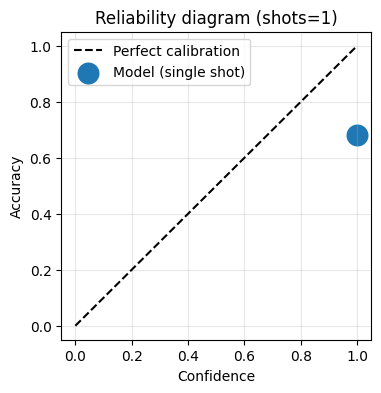

In [5]:
def reliability_bins(y_true, p_pred, n_bins=10):
    confidences = p_pred.max(axis=1)
    predictions = p_pred.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_conf, bin_acc, bin_weight = [], [], []
    for i in range(n_bins):
        upper = bins[i + 1]
        mask = (
            (confidences >= bins[i]) & (confidences <= upper)
            if i == n_bins - 1
            else (confidences >= bins[i]) & (confidences < upper)
        )
        if not np.any(mask):
            continue
        bin_conf.append(confidences[mask].mean())
        bin_acc.append(accuracies[mask].mean())
        bin_weight.append(mask.mean())
    return np.array(bin_conf), np.array(bin_acc), np.array(bin_weight)


bin_conf, bin_acc, bin_weight = reliability_bins(y_test, probs_single)

plt.figure(figsize=(4, 4))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.scatter(bin_conf, bin_acc, s=200 * bin_weight + 20, label="Model (single shot)")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability diagram (shots=1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("ece_bugfix_reliability_diagram.png", bbox_inches="tight")
plt.show()

## Summary

- `ece()` now includes confidence-exactly-1.0 predictions in the last bin
  (fix in `quantumuq/core/metrics.py`).
- A regression test (`test_ece_counts_full_confidence_predictions`) in
  `tests/test_metrics.py` locks this in.
- Practically, this matters most in low-shot regimes, where quantum
  measurement outcomes saturate to exact 0/1 probabilities -- exactly the
  points the old code was dropping.